In [138]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src import (
    QlearningGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In this notebook I analyse the simulations where $v_1$ = $v_2$ = 0.5. These are the simulations performed in Experiment 2, they give the algorithms expanded bid options above the symmetric value they assign the object. These simulations gave results in which tacit collusion occured between Q-learners also in the SPA. This notebook aims to understand how and why this was happening.

In [35]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

#run simulation for FPA or SPA
simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
FPA_baseline = simulation.run()

Convergence detected after 59182 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


In [36]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
SPA_baseline = simulation.run()

Convergence detected after 228774 rounds.
Bidder Agent1 had converged to  0.9500000000000001
Bidder Agent2 had converged to  0.9500000000000001


In [37]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

#run simulation for FPA or SPA
simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
FPA_expanded = simulation.run()

Convergence detected after 82163 rounds.
Bidder Agent1 had converged to  0.2
Bidder Agent2 had converged to  0.2


In [49]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
SPA_expanded = simulation.run()

Convergence detected after 99482 rounds.
Bidder Agent1 had converged to  0.15000000000000002
Bidder Agent2 had converged to  0.15000000000000002


In [50]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

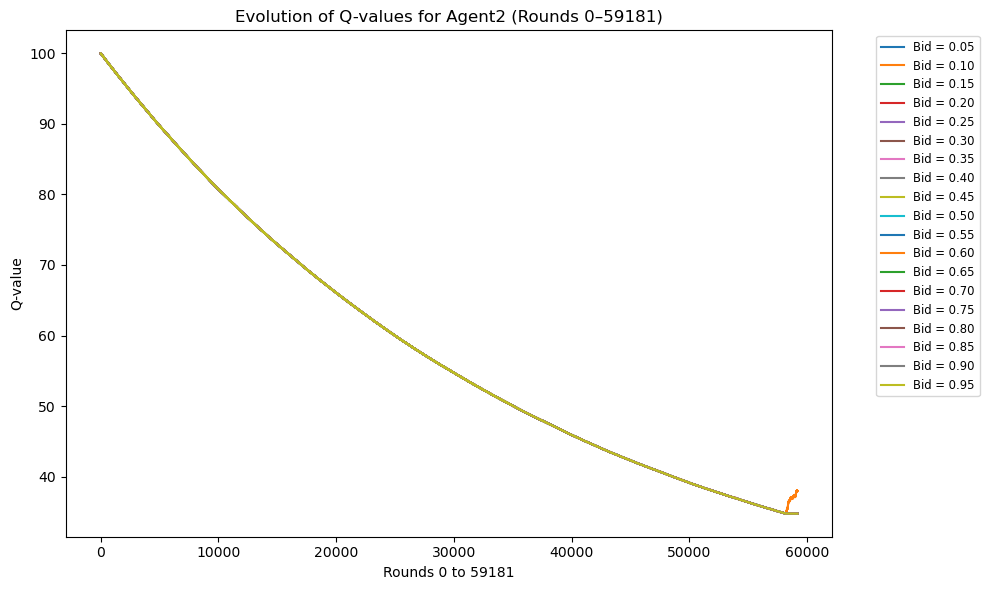

In [127]:
def plot_q_evolution_range(history, bidder_name, start_round, end_round, n_bids = 19, title=None, save=False):
    """
    Plot Q-value trajectories for all bids of `bidder_name` between
    start_round and end_round (inclusive).
    
    Parameters
    ----------
    history : list
        Auction history, where each element ends with q_snapshot: {bidder_name: q_values}.
    bidder_name : str
        Name of the bidder to plot.
    start_round : int
        Index of the starting round (0-based).
    end_round : int
        Index of the ending round (0-based, inclusive).
    """
    n = len(history)
    if n == 0:
        raise ValueError("History is empty.")
    if start_round < 0 or end_round >= n:
        raise ValueError(f"start_round and end_round must be within [0, {n-1}].")
    if end_round < start_round:
        raise ValueError("end_round must be greater than or equal to start_round.")

    # Slice history for the given range
    hist_slice = history[start_round:end_round+1]

    # Bid grid (same as in your environment)
    bid_options = np.array([i*0.05 for i in range(1, n_bids+1)])
    num_bids = len(bid_options)

    # Plot trajectories
    plt.figure(figsize=(10, 6))
    for bid_idx in range(num_bids):
        q_traj = extract_q_trajectory(hist_slice, bidder_name, bid_idx)
        plt.plot(range(start_round, end_round+1), q_traj, label=f"Bid = {bid_options[bid_idx]:.2f}")

    plt.xlabel(f"Rounds {start_round} to {end_round}")
    plt.ylabel("Q-value")
    plt.title(f"Evolution of Q-values for {bidder_name} (Rounds {start_round}–{end_round})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")
    plt.tight_layout()
    if save == True:
        plt.savefig(f"{title}.pdf")
    plt.show()

plot_q_evolution_range(FPA_baseline, "Agent2", 0, 59181)

array([  32., 1028.,   28.,   36.,   46.,   53.,   38.,   61.,   67.,
         91.,   65.,   68.,   58.,   86.,   63.,   62.,   45.,   40.,
         33.])

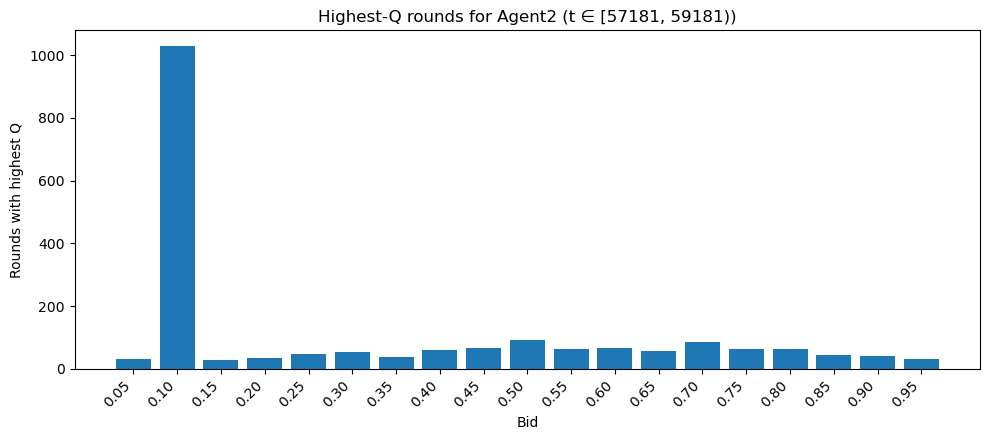

In [129]:
def plot_top_q_counts(history, bidder_name, start=0, end=None, n_bid=19,
                      tie="split", seed=None, ax=None):
    """
    Count and plot how many rounds each bid (0.05..0.95, step 0.05) had the highest Q
    for `bidder_name` between rounds [start, end).

    tie: "split" -> split a round equally among all top-tying bids (default)
         "all"   -> give a full count to every top-tying bid
         "random"-> break ties randomly (use `seed` for reproducibility)

    Returns: counts as a numpy array of length 19, aligned with bid_grid.
    """
    bid_grid = np.array([i * 0.05 for i in range(1, n_bid+1)])  # 0.05..0.95
    n_bids = len(bid_grid)

    if end is None:
        end = len(history)
    if not (0 <= start < end <= len(history)):
        raise ValueError("Invalid start/end window.")
    if len(history) == 0:
        raise ValueError("Empty history.")

    first_q = history[0][-1][bidder_name]
    if len(first_q) != n_bids:
        raise ValueError(f"Expected {n_bids} actions, found {len(first_q)} in Q-vector.")

    # Q matrix shape: (n_bids, T_window)
    Q = np.vstack([extract_q_trajectory(history, bidder_name, i) for i in range(n_bids)])
    Q = Q[:, start:end]
    T = Q.shape[1]
    if T == 0:
        raise ValueError("Empty window: no rounds to analyze.")

    counts = np.zeros(n_bids, dtype=float)

    if tie == "split":
        col_max = np.max(Q, axis=0)
        is_top = (Q == col_max)
        denom = is_top.sum(axis=0)          # number of top ties per round
        weights = np.where(denom > 0, 1.0 / denom, 0.0)
        counts = (is_top * weights).sum(axis=1)
    elif tie == "all":
        col_max = np.max(Q, axis=0)
        is_top = (Q == col_max)
        counts = is_top.sum(axis=1).astype(float)
    elif tie == "random":
        rng = np.random.default_rng(seed)
        for t in range(T):
            col = Q[:, t]
            top_val = np.max(col)
            top_idx = np.flatnonzero(col == top_val)
            pick = rng.choice(top_idx)
            counts[pick] += 1.0
    else:
        raise ValueError("tie must be one of {'split','all','random'}")

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(n_bids)
    ax.bar(x, counts)
    ax.set_ylabel("Rounds with highest Q")
    ax.set_xlabel("Bid")
    ax.set_xticks(x, [f"{b:.2f}" for b in bid_grid], rotation=45, ha="right")
    ax.set_title(f"Highest-Q rounds for {bidder_name} (t ∈ [{start}, {end}))")
    plt.tight_layout()

    return counts

plot_top_q_counts(FPA_baseline, "Agent2", 57181, 59181)

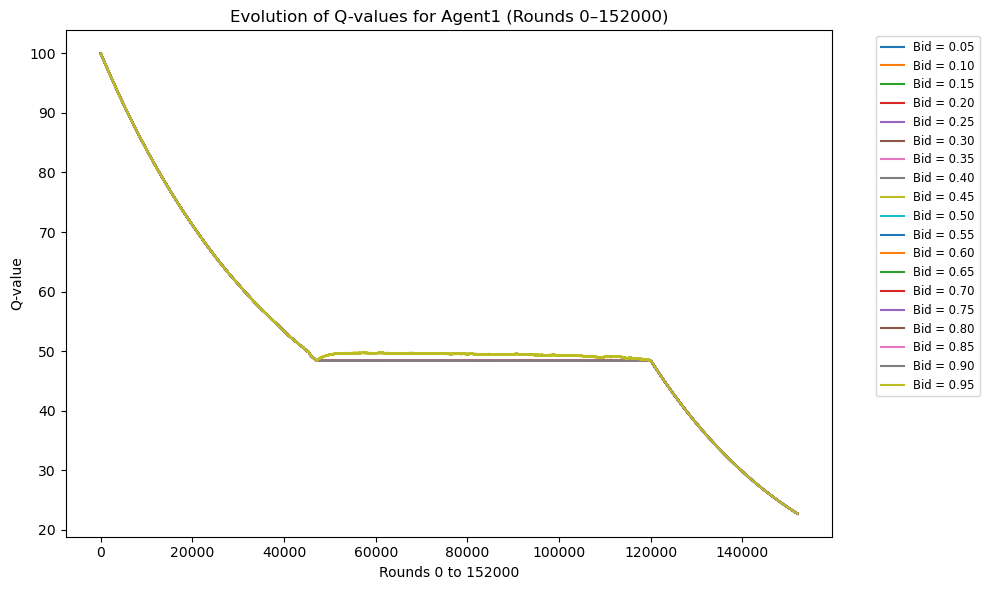

In [55]:
plot_q_evolution_range(SPA_baseline, "Agent1", 0, 152000)

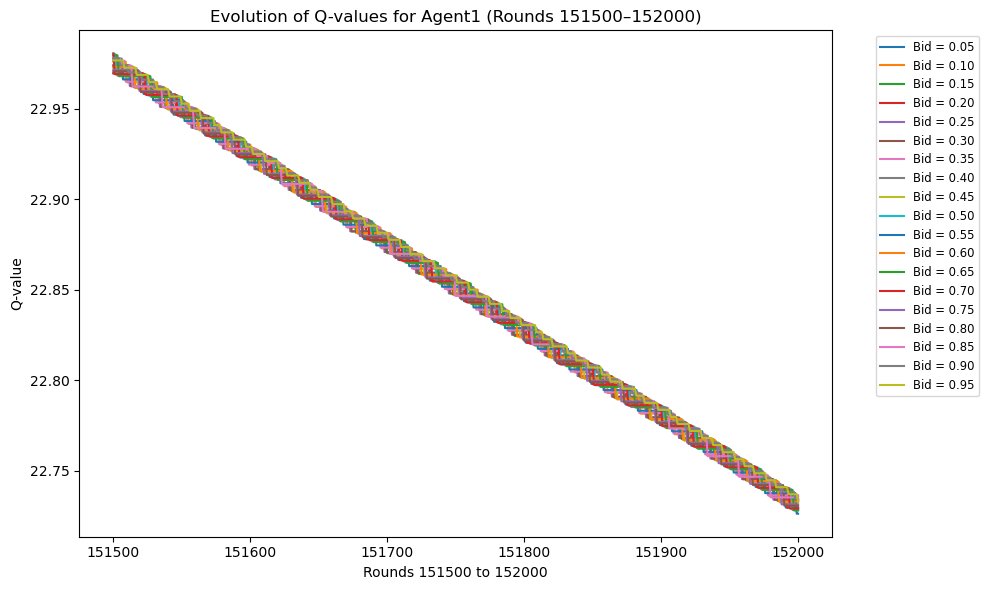

In [56]:
plot_q_evolution_range(SPA_baseline, "Agent1", 151500, 152000)

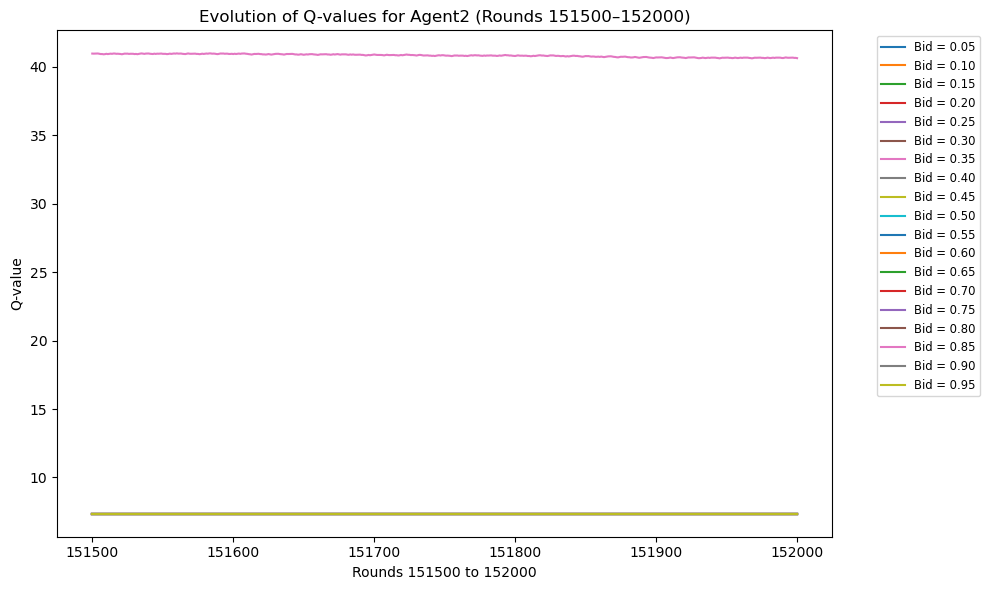

In [57]:
plot_q_evolution_range(SPA_baseline, "Agent2", 151500, 152000)

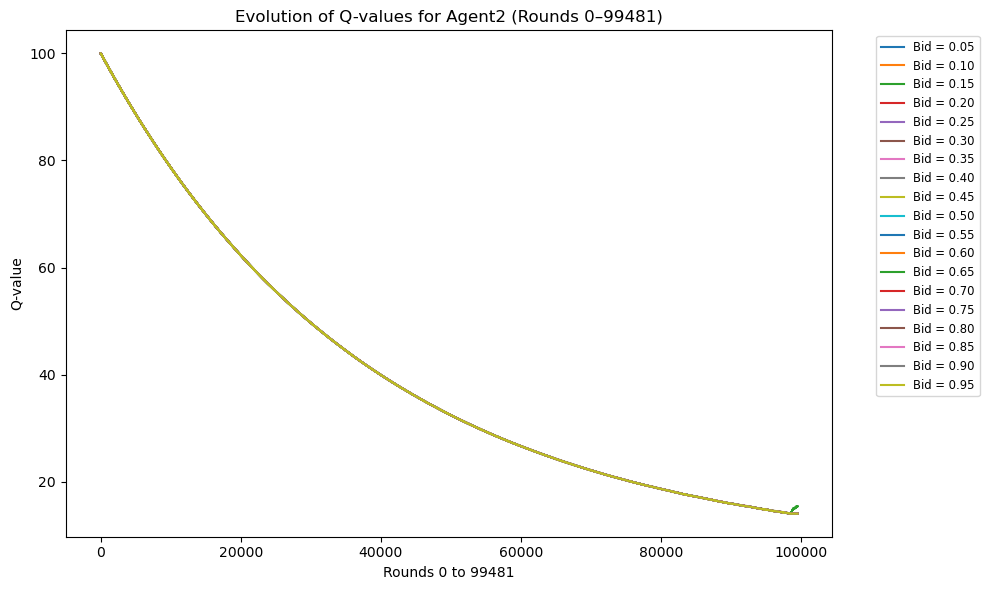

In [59]:
plot_q_evolution_range(SPA_expanded, "Agent2", 0, 99481)

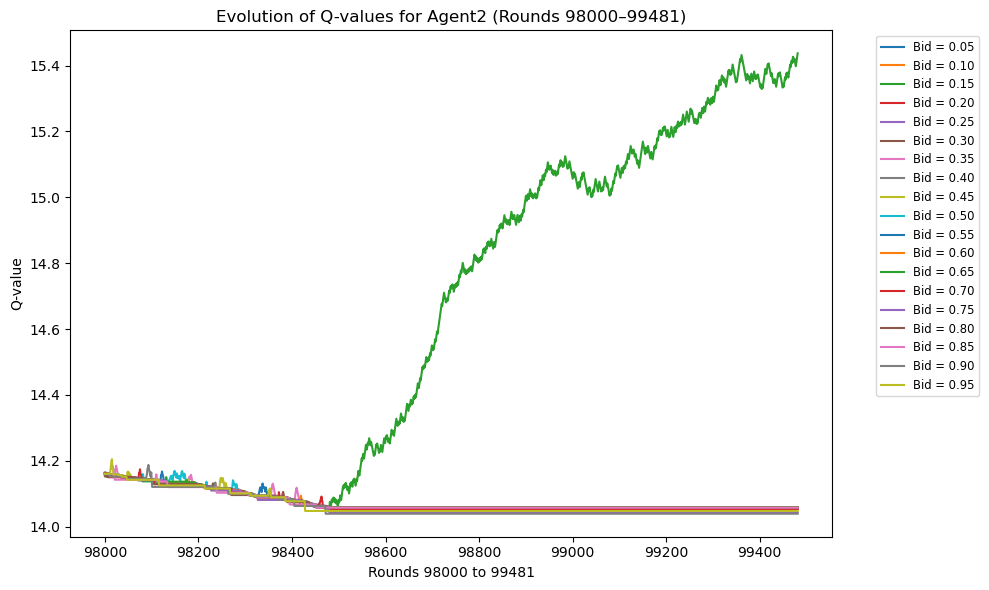

In [60]:
plot_q_evolution_range(SPA_expanded, "Agent2", 98000, 99481)

array([13., 16., 31., 15., 32., 18., 20., 39., 48., 56., 36., 22., 20.,
       38., 30., 10., 11., 17., 28.])

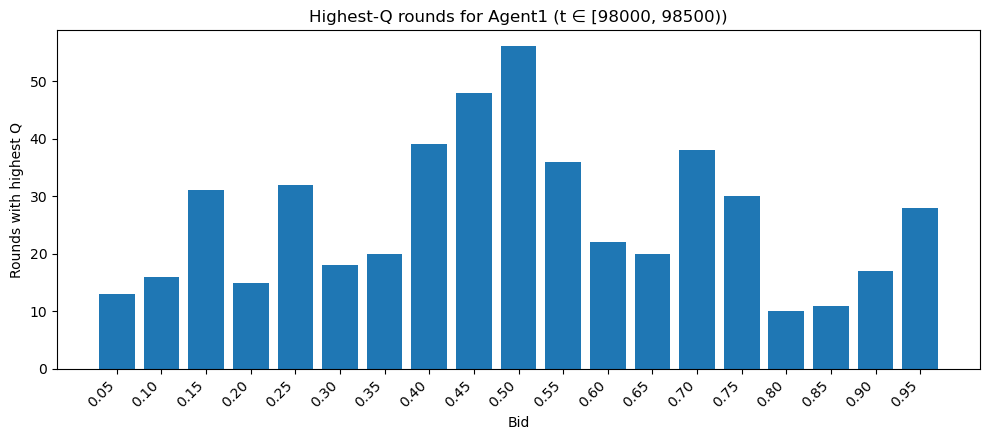

In [132]:
plot_top_q_counts(SPA_expanded, "Agent1", 98000, 98500)

In [146]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
SPA_expanded_no_convergence = simulation.run()

Agents have not converged after 1,000,000 rounds


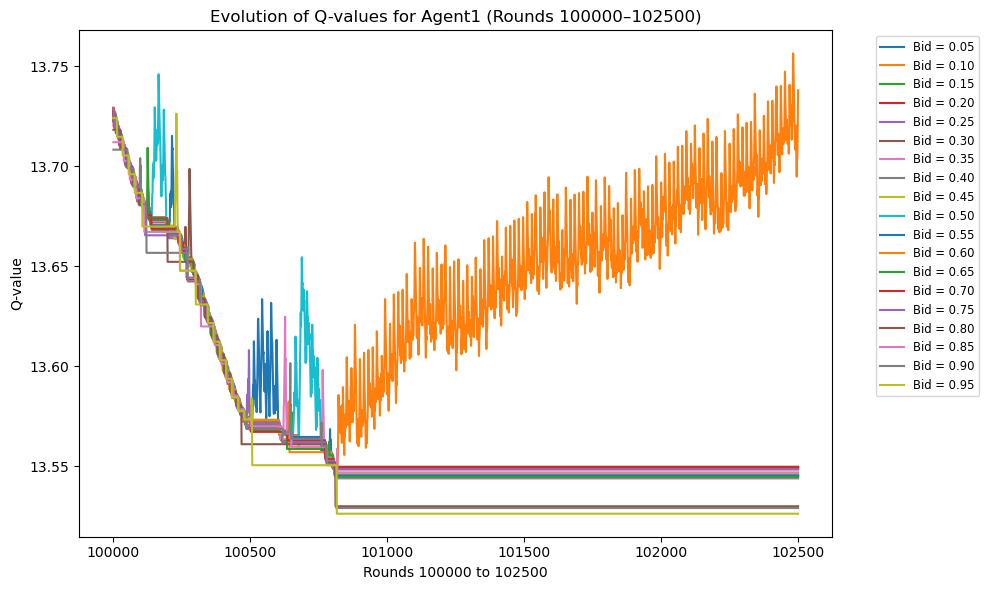

In [149]:
plot_q_evolution_range(SPA_expanded_no_convergence, "Agent1", 100000, 102500, title="SPA_no_convergence_q_values", save=True)

array([  40.,   43.,   40.,   43.,   40.,   40.,   61.,   48.,   40.,
         67.,   40., 1780.,   44.,   24.,   25.,   34.,   38.,   24.,
         29.])

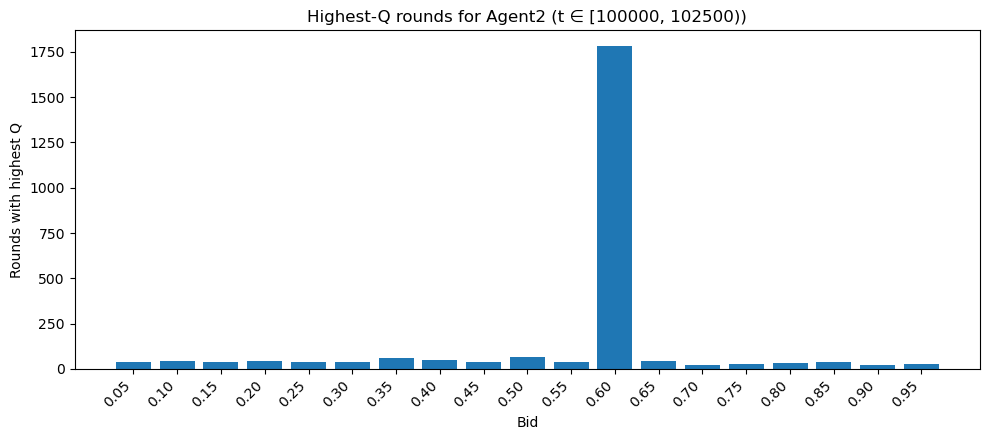

In [70]:
plot_top_q_counts(SPA_expanded_no_convergence, "Agent2", 100000, 102500)

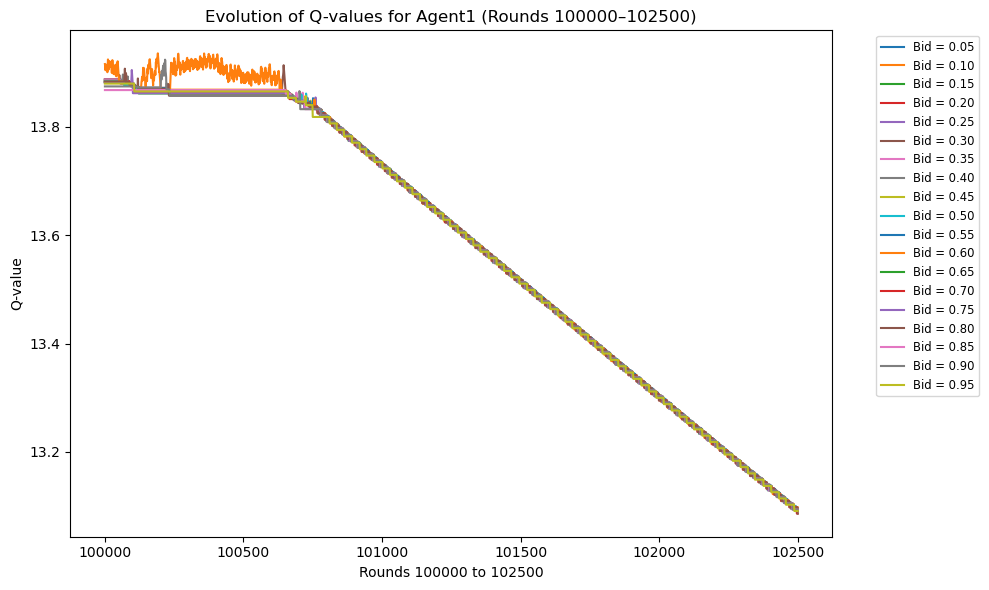

In [67]:
plot_q_evolution_range(SPA_expanded_no_convergence, "Agent1", 100000, 102500)

array([117., 117., 118., 118., 121., 132., 124., 137., 119., 128., 124.,
       622.,  70.,  72.,  72.,  83.,  67.,  91.,  68.])

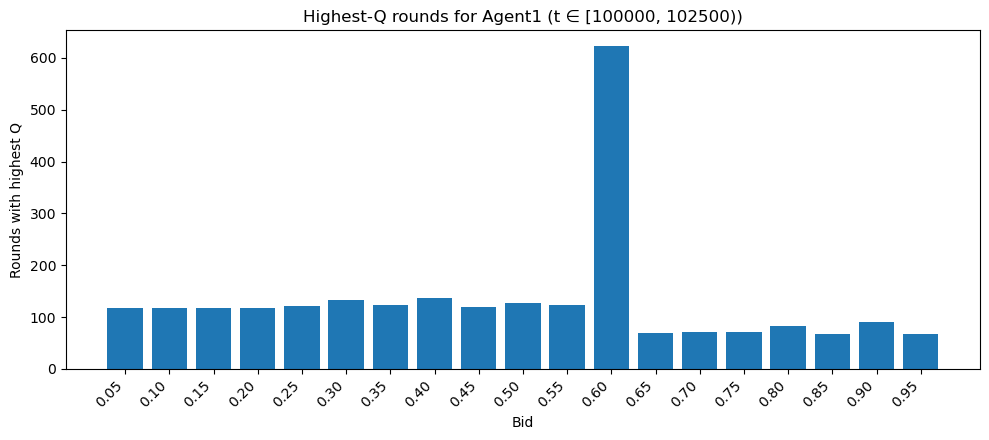

In [68]:
plot_top_q_counts(SPA_expanded_no_convergence, "Agent1", 100000, 102500)

In [123]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, num_bids=30)
bidder2 = EpsilonGreedy(name="Agent2", value=0.5, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=100, num_bids=30)

#run simulation for FPA or SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
SPA_expanded_further = simulation.run()

Convergence detected after 114972 rounds.
Bidder Agent1 had converged to  0.1
Bidder Agent2 had converged to  0.1


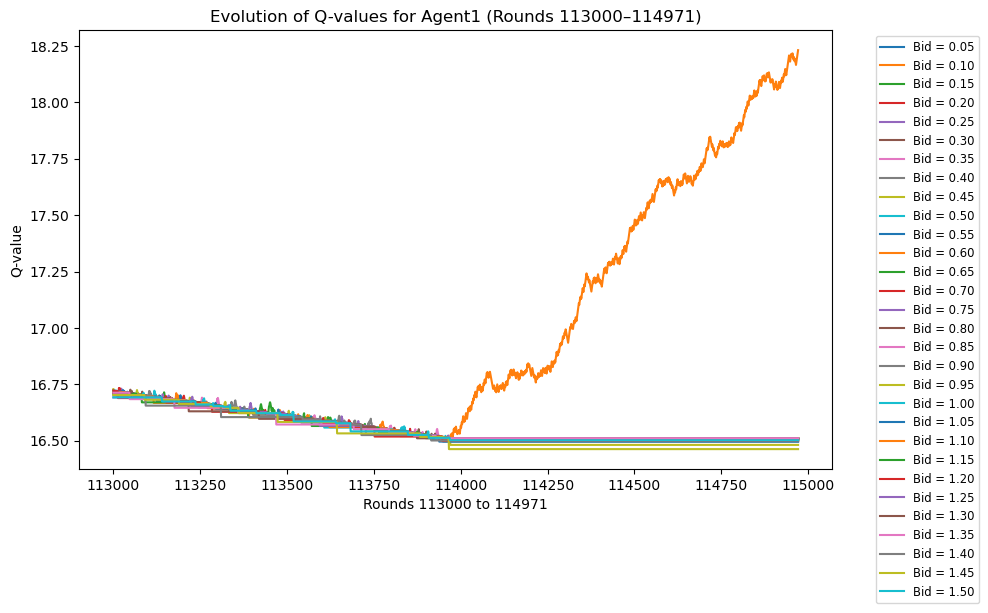

In [128]:
plot_q_evolution_range(SPA_expanded_further, "Agent1", 113000, 114971, n_bids=30)

array([25., 58., 25., 28., 36., 46., 54., 57., 46., 49., 48., 55., 71.,
       44., 50., 24., 31., 39., 18., 35., 24., 14., 17., 16., 18., 14.,
        8., 13., 15., 22.])

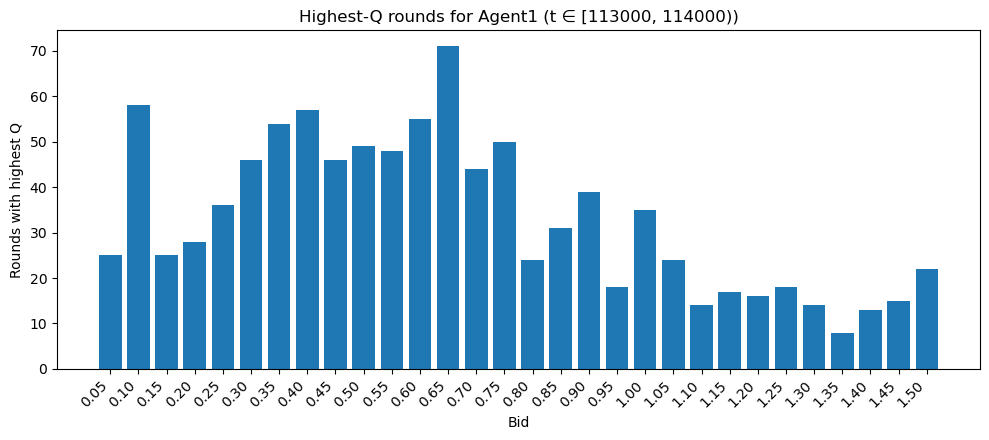

In [131]:
plot_top_q_counts(SPA_expanded_further, "Agent1", 113000, 114000, n_bid=30)

In [142]:
SPA_extended = []
convergence_rates = []
total = 100
bid_range = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
for i in range(1, len(bid_range)):
    df = pd.read_csv(f"Results_SPA/Bids extension/SPA_bids_extended_{bid_range[i]}.csv")
    SPA_extended.append(df)
    converged = df["rounds_to_convergence"].notna().sum()
    convergence_rates.append(100 * converged / total)

del df

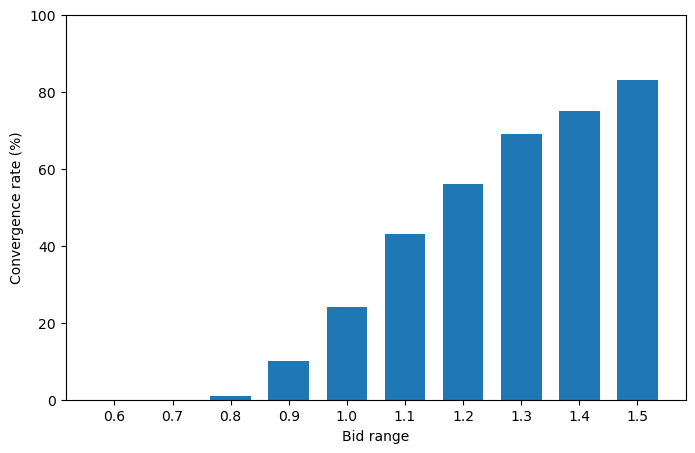

In [150]:
plt.figure(figsize=(8, 5))
plt.bar(bid_range[1:], convergence_rates, width=0.07, align="center")
plt.xlabel("Bid range")
plt.ylabel("Convergence rate (%)")
plt.xticks(bid_range[1:])
plt.ylim(0, 100)
plt.savefig(f"SPA_percentage_simulations_converged.pdf")
plt.show()